This notebook was (heavily) inspired from [PyTorch Documentation](https://pytorch.org/docs/stable/index.html) and [this post](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
).

# Numpy to PyTorch

<svg xmlns="http://www.w3.org/2000/svg" width="480" height="200" viewBox="0 0 600 250">
<g transform="translate(10,10) scale(0.4)"><polygon fill="#4DABCF" points="220.93 127.14 151.77 92.23 75.87 130.11 146.9 165.78 220.93 127.14"/><polygon fill="#4DABCF" points="252.63 143.14 325.14 179.74 249.91 217.52 178.77 181.79 252.63 143.14"/><polygon fill="#4DABCF" points="349.47 92.76 423.96 130.11 357.34 163.57 284.68 126.92 349.47 92.76"/><polygon fill="#4DABCF" points="317.41 76.67 250.35 43.05 184.01 76.15 253.11 111 317.41 76.67"/><polygon fill="#4DABCF" points="264.98 365.44 264.98 456.95 346.22 416.41 346.13 324.86 264.98 365.44"/><polygon fill="#4DABCF" points="346.1 292.91 346.01 202.32 264.98 242.6 264.98 333.22 346.1 292.91"/><polygon fill="#4DABCF" points="443.63 275.93 443.63 367.8 374.34 402.38 374.29 310.93 443.63 275.93"/><polygon fill="#4DABCF" points="443.63 243.81 443.63 153.79 374.21 188.3 374.27 279.07 443.63 243.81"/><path fill="#4D77CF" d="M236.3,242.6l-54.72-27.51V334s-66.92-142.39-73.12-155.18c-.8-1.65-4.09-3.46-4.93-3.9-12-6.3-47.16-24.11-47.16-24.11V360.89l48.64,26V277.08s66.21,127.23,66.88,128.62,7.32,14.8,14.42,19.51c9.46,6.26,50,30.64,50,30.64Z"/></g>
<text x="110" y="235" fill="#4D77CF" font-family="Helvetica, Arial, sans-serif" font-size="26" font-weight="bold" text-anchor="middle">NumPy</text>
<g fill="none" stroke="#555555" stroke-width="10" stroke-linecap="round" stroke-linejoin="round">
<path d="M240 110 H350"/><path d="M320 80 L355 110 L320 140"/></g>
<g transform="translate(435,20) scale(1.65) translate(-0.6,-1067.9)"><path fill="#EE4C2C" d="M77.6,1099.6l-8.1,8.1c13.3,13.3,13.3,34.7,0,47.8c-13.3,13.3-34.7,13.3-47.8,0 c-13.3-13.3-13.3-34.7,0-47.8l0,0l21.1-21.1l3-3l0,0v-15.9l-31.8,31.8c-17.7,17.7-17.7,46.3,0,64c17.7,17.7,46.3,17.7,63.7,0 C95.3,1145.8,95.3,1117.4,77.6,1099.6z"/> <circle fill="#EE4C2C" cx="61.7" cy="1091.8" r="5.9"/></g>
<text x="510" y="235" fill="#EE4C2C" font-family="Helvetica, Arial, sans-serif" font-size="26" font-weight="bold" text-anchor="middle">PyTorch</text>
</svg>

[Each question is followed by an empty cell: write your answer there. Use PyTorch for all questions, unless stated otherwise.]

In [78]:
# !pip install torchviz
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LinearRegression
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchviz import make_dot


## Introduction to PyTorch

*In this first section, we discover the `torch.Tensor`: it behaves almost exactly like a `np.ndarray`, with two extra super-powers (running on a GPU, and computing its own gradients).*

Create a tensor directly from the python list `[[1, 2], [3, 4]]`, using `torch.tensor`.

In [36]:
torch.Tensor([[1,2], [3,4]])

tensor([[1., 2.],
        [3., 4.]])

Create the same tensor, but from a numpy array this time (`np.array`, then `torch.from_numpy`).

In [37]:
x = np.array([[1,2],[3,4]])
torch.from_numpy(x)
torch.tensor(x)

tensor([[1, 2],
        [3, 4]])

Create tensors *shaped like* an existing one: one filled with ones, one filled with zeros of `dtype=torch.float`, and one filled with random values.

*Hint: `torch.ones_like`, `torch.zeros_like`, `torch.rand_like`.*

In [38]:
0.1 + 0.2

0.30000000000000004

In [39]:
x = torch.ones(4, dtype=torch.float32)
x, torch.zeros_like(x)


(tensor([1., 1., 1., 1.]), tensor([0., 0., 0., 0.]))

In [40]:
torch.random.manual_seed(0)
torch.randn(6)

tensor([ 1.5410, -0.2934, -2.1788,  0.5684, -1.0845, -1.3986])

Create a random tensor of shape $3 \times 4$ (`torch.rand`), and print its three main attributes: `.shape`, `.dtype` and `.device`.

In [41]:
x = torch.rand( (3, 4) )
x.shape, x.dtype, x.device

(torch.Size([3, 4]), torch.float32, device(type='cpu'))

Move your tensor to the GPU (if you have one available), and print its device again.

*Hint: `torch.cuda.is_available()` and `.to("cuda")`.*

In [42]:
if torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

x.to(DEVICE)

tensor([[0.0223, 0.1689, 0.2939, 0.5185],
        [0.6977, 0.8000, 0.1610, 0.2823],
        [0.6816, 0.9152, 0.3971, 0.8742]])

What happens if you try to add a tensor living on the CPU and a tensor living on the GPU?

*Answer:*

Slicing and assignment work exactly like in numpy. Create a $4 \times 4$ tensor of ones, then set its column $1$ to $0$ and its row $2$ to $-1$. Print the first row, the first column and the last row.

In [43]:
x = torch.ones( (4, 4) )
x[:, 1:3] = 0
x[2, :] = -1
x[0,0] = 3
x[:, 0], x[-1, :]


(tensor([ 3.,  1., -1.,  1.]), tensor([1., 0., 0., 1.]))

Concatenate three copies of that tensor, first along `dim=1`, then along `dim=0` (`torch.cat`). What is the shape of each result?

In [44]:
x, torch.cat([x, x, x], dim=1)

(tensor([[ 3.,  0.,  0.,  1.],
         [ 1.,  0.,  0.,  1.],
         [-1., -1., -1., -1.],
         [ 1.,  0.,  0.,  1.]]),
 tensor([[ 3.,  0.,  0.,  1.,  3.,  0.,  0.,  1.,  3.,  0.,  0.,  1.],
         [ 1.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  1.,  0.,  0.,  1.],
         [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
         [ 1.,  0.,  0.,  1.,  1.,  0.,  0.,  1.,  1.,  0.,  0.,  1.]]))

Compute, on that same tensor:
- the matrix product $t \, t^{T}$, in two ways (`@` and `.matmul`)
- the element-wise product $t * t$, in two ways (`*` and `.mul`)
- the sum of all its elements (`.sum()`)

In [45]:
x

tensor([[ 3.,  0.,  0.,  1.],
        [ 1.,  0.,  0.,  1.],
        [-1., -1., -1., -1.],
        [ 1.,  0.,  0.,  1.]])

In [46]:
x.sum(axis=0)

tensor([ 4., -1., -1.,  2.])

In [47]:
x@x.T , x.matmul(x.T), torch.matmul(x, x.T)

(tensor([[10.,  4., -4.,  4.],
         [ 4.,  2., -2.,  2.],
         [-4., -2.,  4., -2.],
         [ 4.,  2., -2.,  2.]]),
 tensor([[10.,  4., -4.,  4.],
         [ 4.,  2., -2.,  2.],
         [-4., -2.,  4., -2.],
         [ 4.,  2., -2.,  2.]]),
 tensor([[10.,  4., -4.,  4.],
         [ 4.,  2., -2.,  2.],
         [-4., -2.,  4., -2.],
         [ 4.,  2., -2.,  2.]]))

In [48]:
x.T, x

(tensor([[ 3.,  1., -1.,  1.],
         [ 0.,  0., -1.,  0.],
         [ 0.,  0., -1.,  0.],
         [ 1.,  1., -1.,  1.]]),
 tensor([[ 3.,  0.,  0.,  1.],
         [ 1.,  0.,  0.,  1.],
         [-1., -1., -1., -1.],
         [ 1.,  0.,  0.,  1.]]))

Convert a tensor back to a numpy array (`.numpy()`).

In [49]:
x.numpy()

array([[ 3.,  0.,  0.,  1.],
       [ 1.,  0.,  0.,  1.],
       [-1., -1., -1., -1.],
       [ 1.,  0.,  0.,  1.]], dtype=float32)

Everything above is just numpy with extra steps. **The real added value of PyTorch is that a tensor can compute its own gradients.**

Create `a = torch.randn(5)` and `x = torch.randn(5, requires_grad=True)`, then compute $y = \sum_i a_i x_i$ (`torch.sum(a*x)`).

Print `x.grad`: what do you get?

Then call `y.backward()` and print `x.grad` again.

In [50]:
a = torch.randn(5)
x = torch.randn(5, requires_grad=True)
a, x

(tensor([-0.8567,  1.1006, -1.0712,  0.1227, -0.5663]),
 tensor([ 0.3731, -0.8920, -1.5091,  0.3704,  1.4565], requires_grad=True))

In [51]:
x.grad

In [52]:
y = (a*x).sum()
y.backward()

In [53]:
x, x.grad

(tensor([ 0.3731, -0.8920, -1.5091,  0.3704,  1.4565], requires_grad=True),
 tensor([-0.8567,  1.1006, -1.0712,  0.1227, -0.5663]))

Is the gradient you obtained the one you expected? Compute $\frac{\partial y}{\partial x_i}$ by hand and compare.

*Answer:*

Call `y.backward()` a second time. Explain the result obtained.

In [54]:
# y.backward()

*Answer:*

Call `backward()` twice on a freshly recomputed `y`.
What happens to `x.grad`?
What if you use `x.grad.zero_()` in between?

In [55]:
y = (a*x).sum()
y.backward()

-----

## Differentiating in three ways

- $f(x) = \frac{x^2}{5}+ \cos x$
- $z(x,y) = \frac{x}{y} + \cos x * \sin y$


We will differentiate $f$ (and then $z$) in three different ways, and check that the three give the same answer.

#### Using symbolic differentiation

Compute $f'$ by hand, then write the two python functions `f(x)` and `df(x)` (with numpy), and plot both on $[-3, 3]$ (use `np.linspace` with $100$ points).

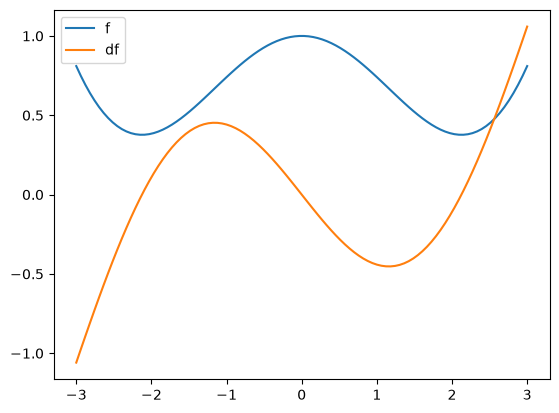

In [56]:
def f(x):
    return (x**2)/5 + np.cos(x)

def df(x):
    return 2*x/5 - np.sin(x)

xs = np.linspace(-3, 3, 100)
plt.plot(xs, f(xs), label='f')
plt.plot(xs, df(xs), label='df')
plt.legend()
plt.show()

#### Using finite differences

Now write `df` *without* knowing the analytical derivative, using the centered finite difference:

$f'(x) \approx \frac{f(x+\epsilon) - f(x-\epsilon)}{2\epsilon}$

with $\epsilon = 10^{-3}$. Plot it on top of the previous one to check they match.

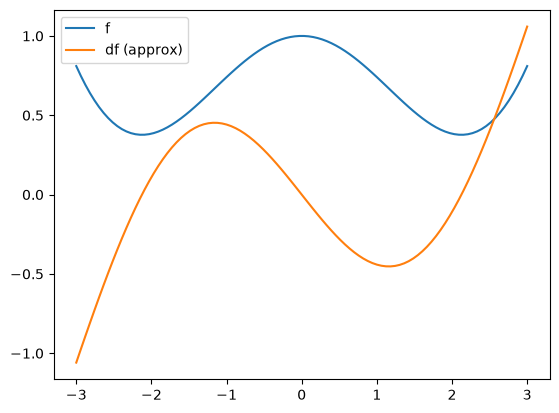

In [57]:
def df_approx(x, eps=1e-3):
    return (f(x+eps)-f(x-eps))/(2*eps)

xs = np.linspace(-3, 3, 100)
plt.plot(xs, f(xs), label='f')
plt.plot(xs, df_approx(xs), label='df (approx)')
plt.legend()
plt.show()

Try again with a much smaller $\epsilon$ (say $10^{-12}$, then $10^{-20}$). What happens, and why?

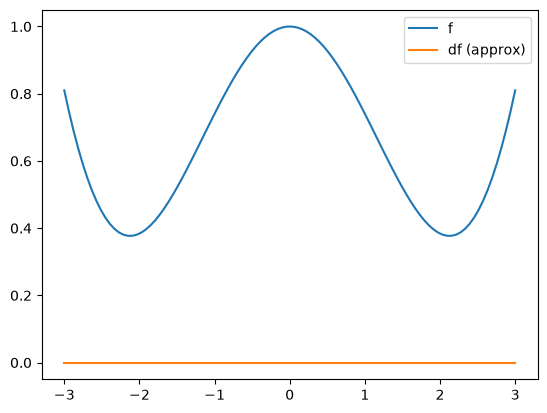

In [58]:
def df_approx(x, eps=1e-20):
    return (f(x+eps)-f(x-eps))/(2*eps)

xs = np.linspace(-3, 3, 100)
plt.plot(xs, f(xs), label='f')
plt.plot(xs, df_approx(xs), label='df (approx)')
plt.legend()
plt.show()

*Answer:*

#### Using PyTorch's autograd

Rewrite `f` with torch operations (`torch.cos` instead of `np.cos`), create `x = torch.linspace(-3, 3, 100, requires_grad=True)`, and compute `y = f(x)`.

Call `y.sum().backward()`, and read the derivative in `x.grad`.

*Hint: `backward()` only works on a scalar; summing over the $100$ points is a trick to get all $100$ derivatives at once, since $\frac{\partial}{\partial x_i} \sum_j f(x_j) = f'(x_i)$.*

*Hint: to plot a tensor that requires grad, you need to detach it first: `plt.plot(x.detach(), y.detach())`.*

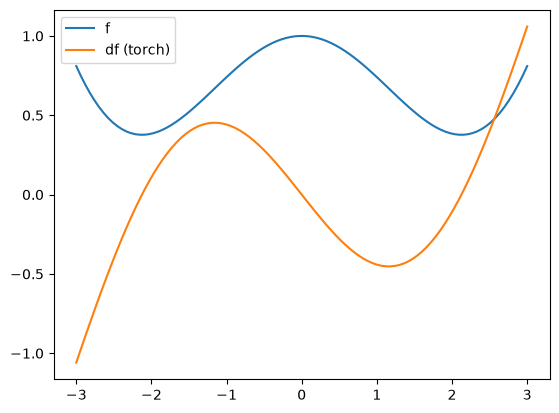

In [59]:
def f_torch(x):
    return (x**2)/5 + torch.cos(x)

x = torch.linspace(-3, 3, 100, requires_grad=True)
y = f_torch(x)
y.sum().backward()

plt.plot(x.detach(), y.detach(), label='f')
plt.plot(x.detach(), x.grad, label='df (torch)')
plt.legend()
plt.show()

Do the same for $z(x,y) = \frac{x}{y} + \cos x * \sin y$: compute $\frac{\partial z}{\partial x}$ and $\frac{\partial z}{\partial y}$ at a few points with autograd, and check them against the derivatives you compute by hand.

*Hint: this time you have two tensors with `requires_grad=True`; after `backward()`, each of them carries its own `.grad`.*

Which of the three methods would you use for a neural network with a million parameters? Why?

*Answer:*

-----

## Torching a linear regression

Here is the linear regression by gradient descent we wrote in numpy last week (compared to the analytical solution of `sklearn`). **Run it**, keep the data (`xs`, `ys`) and the reference values (`skl_a`, `skl_b`): we are going to rewrite this exact same training, step by step, in PyTorch.

Numpy:   [1.02151009] [1.95402174]
SKlearn: [1.02150962] [1.95402268]


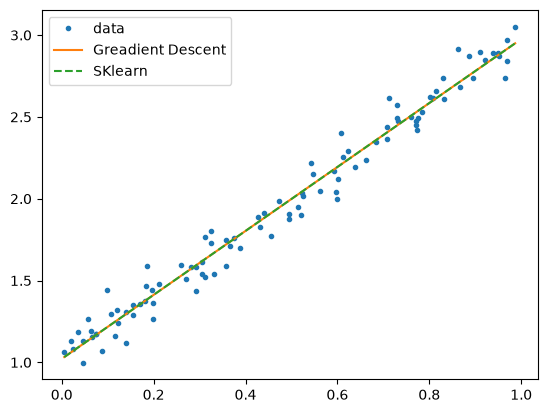

In [60]:
# Data Generation
np.random.seed(42)
xs = np.random.rand(100, 1)
ys = 1 + 2 * xs + .1 * np.random.randn(100, 1)
plt.plot(xs, ys, '.', label='data')

np.random.seed(42)
a = np.random.randn(1)  # a + b * xs
b = np.random.randn(1)  # a + b * xs

lr = 1e-1
n_epochs = 1000
for epoch in range(n_epochs):
    # compute our model's predicted output
    yhat = a + b * xs
    
    # compute the error
    error = (ys - yhat)
    # compute the loss (MSE)
    loss = (error ** 2).mean()
    
    # compute gradients for both a and b parameters
    a_grad = -2 * error.mean()
    b_grad = -2 * (xs * error).mean()
    
    # update parameters using gradients and the learning rate
    a = a - lr * a_grad
    b = b - lr * b_grad
print('Numpy:  ', a, b)
plt.plot([np.min(xs), np.max(xs)], [a+np.min(xs)*b,a+np.max(xs)*b], "-", label='Greadient Descent')


linr = LinearRegression()
linr.fit(xs, ys)
skl_a = linr.intercept_
skl_b = linr.coef_[0]
plt.plot([np.min(xs), np.max(xs)], [skl_a+np.min(xs)*skl_b,skl_a+np.max(xs)*skl_b], "--", label='SKlearn')
plt.legend()
plt.plot()

print('SKlearn:', skl_a, skl_b)

First, define the best device available (`'cuda'` if a GPU is available, `'cpu'` otherwise).

In [61]:
if torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

Transform the numpy arrays `xs` and `ys` into torch tensors of type `float`, and send them to that device.

*Hint: `torch.from_numpy(...).float().to(device)`.*

Print `type(xs)`, `type(xs_tensor)` and `xs_tensor.type()` to see the difference.

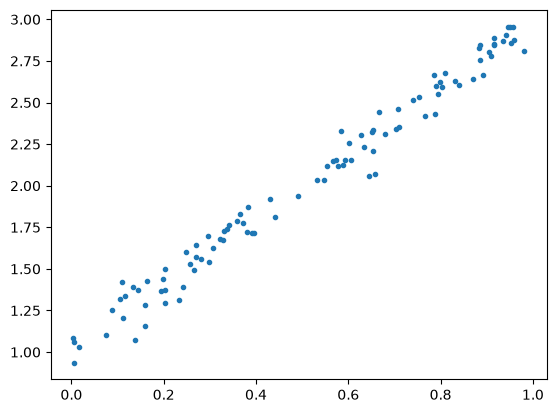

In [69]:
# Data Generation
torch.manual_seed(42)
xs_tensor = torch.rand(100, 1).float().to(DEVICE)
ys_tensor = 1 + 2 * xs_tensor + .1 * torch.randn(100, 1).float().to(DEVICE)

plt.plot(xs_tensor, ys_tensor, '.', label='data')


Initialize the parameters $a$ and $b$ randomly (`torch.randn`). Since we want to apply gradient descent on them, do not forget `requires_grad=True` (and `dtype=torch.float`, `device=device`).

*Use `torch.manual_seed(42)` so that your results are reproducible.*

In [70]:
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs

Rewrite the main gradient descent loop ($1000$ epochs, $lr = 0.1$), but let PyTorch compute the gradients for you:
- compute `yhat`, `error` and `loss` exactly as before
- use `loss.backward()` to get the gradients instead of writing `a_grad` and `b_grad` by hand
- update the parameters inside a `with torch.no_grad():` block (otherwise PyTorch tries to track the update itself, and complains)
- use `.zero_()` on the gradients of $a$ and $b$ after each update

Print your final $a$ and $b$, and compare them with `skl_a` and `skl_b`.

In [76]:
lr = 1e-1
n_epochs = 1000
for epoch in range(n_epochs):
    # compute our model's predicted output
    yhat = a + b * xs_tensor
    # compute the error
    error = (ys_tensor - yhat)
    # compute the loss (MSE)
    loss = (error ** 2).mean()
    loss.backward() # computing the gradients via auto diff
    # update parameters using gradients and the learning rate
    a = torch.tensor([a[0]-lr*a.grad[0]], requires_grad=True, dtype=torch.float, device=DEVICE)
    b = torch.tensor([b[0]-lr*b.grad[0]], requires_grad=True, dtype=torch.float, device=DEVICE)

print('Torch:  ', a, b)
print('SKlearn:', skl_a, skl_b)

Torch:   tensor([1.0231], requires_grad=True) tensor([1.9538], requires_grad=True)
SKlearn: [1.02150962] [1.95402268]


/tmp/ipykernel_79398/4206118507.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  a = torch.tensor([a[0]-lr*a.grad[0]], requires_grad=True, dtype=torch.float, device=DEVICE)


-----
### Interlude: digging into PyTorch's internal system

We will try to understand this part of the code:
```
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
yhat = a + b * xs_tensor
error = ys_tensor - yhat
loss = (error ** 2).mean()
```
Run it (outside of any loop), then use the `make_dot()` function on `yhat` to see the computational graph PyTorch constructed to get `yhat`.

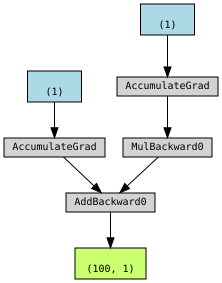

In [81]:
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
yhat = a + b * xs_tensor
error = ys_tensor - yhat
loss = (error ** 2).mean()

make_dot(yhat)

Use `make_dot()` again, on `error` and on `loss`. Watch the graph grow as operations are chained: this graph is exactly what `backward()` walks through, and what gets freed after it.

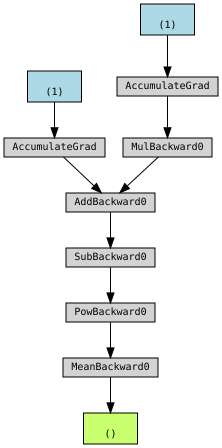

In [82]:
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
yhat = a + b * xs_tensor
error = ys_tensor - yhat
loss = (error ** 2).mean()

make_dot(loss)

What if we did not need the gradient of $a$? Rebuild `yhat` with `a` created with `requires_grad=False`, and plot the computational graph again. What changed?

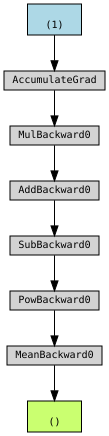

In [83]:
torch.manual_seed(42)
a = torch.randn(1, requires_grad=False, dtype=torch.float, device=DEVICE)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
yhat = a + b * xs_tensor
error = ys_tensor - yhat
loss = (error ** 2).mean()

make_dot(loss)

The graph is built *at runtime*, which means it can depend on python control flow. Add an `if` condition to your loss, for instance:
```
if loss > 0:
    yhat2 = b * xs_tensor
    error2 = ys_tensor - yhat2
loss += error2.mean()
```
and plot the resulting graph.

-----

Getting back to the main gradient descent loop: rewrite it using an **optimizer** instead of updating the parameters by hand (use `optim.SGD([a, b], lr=lr)`).

*Hint: `optimizer.step()` replaces the `with torch.no_grad(): a -= ...`, and `optimizer.zero_grad()` replaces the two `.zero_()`.*

In [96]:
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs
l1 = a**2
l1.backward()
print(a.grad)

l2 = (a-1)**2
l2.backward()
print(a.grad)

a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs
l2 = (a-1)**2
l2.backward()
print(a)



tensor([0.6734])
tensor([-0.6532])
tensor([0.1288], requires_grad=True)


In [97]:
# Data Generation
torch.manual_seed(42)
xs_tensor = torch.rand(100, 1).float().to(DEVICE)
ys_tensor = 1 + 2 * xs_tensor + .1 * torch.randn(100, 1).float().to(DEVICE)

# init params
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs

# main loop
opt = torch.optim.SGD([a, b], lr=1e-1)
n_epochs = 1000
for epoch in range(n_epochs):
    opt.zero_grad()
    # compute our model's predicted output
    yhat = a + b * xs_tensor
    # compute the error
    error = (ys_tensor - yhat)
    # compute the loss (MSE)
    loss = (error ** 2).mean()
    loss.backward() # computing the gradients via auto diff
    # update parameters using gradients and the learning rate
    opt.step()

print('Torch:  ', a, b)
print('SKlearn:', skl_a, skl_b)

Torch:   tensor([1.0231], requires_grad=True) tensor([1.9538], requires_grad=True)
SKlearn: [1.02150962] [1.95402268]


Rewrite the loop again, using PyTorch's MSE (`nn.MSELoss(reduction='mean')`) instead of computing the loss yourself.

In [99]:
# Data Generation
torch.manual_seed(42)
xs_tensor = torch.rand(100, 1).float().to(DEVICE)
ys_tensor = 1 + 2 * xs_tensor + .1 * torch.randn(100, 1).float().to(DEVICE)

# init params
torch.manual_seed(42)
a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)  # a + b * xs

# main loop
opt = torch.optim.SGD([a, b], lr=1e-1)
criterion = torch.nn.MSELoss(reduction='mean')
n_epochs = 1000
for epoch in range(n_epochs):
    opt.zero_grad()
    # compute our model's predicted output
    yhat = a + b * xs_tensor
    # compute the loss (MSE)
    loss = criterion(yhat, ys_tensor)
    loss.backward() # computing the gradients via auto diff
    # update parameters using gradients and the learning rate
    opt.step()

print('Torch:  ', a, b)
print('SKlearn:', skl_a, skl_b)

Torch:   tensor([1.0231], requires_grad=True) tensor([1.9538], requires_grad=True)
SKlearn: [1.02150962] [1.95402268]


Write the linear regression as a `nn.Module` class, and rewrite the training loop using it.

The class must:
- inherit from `nn.Module`, and call `super().__init__()`
- declare $a$ and $b$ as `nn.Parameter(...)` (this is what makes them *real* parameters of the model, visible by `model.parameters()`)
- implement a `forward(self, x)` method returning the prediction

Then build the model with `model = ManualLinearRegression().to(device)`, give `model.parameters()` to the optimizer, and call the model with `model(xs_tensor)`.

At the end, print `dict(model.state_dict())` and compare with `skl_a`, `skl_b`.

In [105]:
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # self.a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
        self.a = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE))
        self.b = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE))

    def forward(self, x):
        return self.a + self.b*x

model = MyModel()
list(model.parameters()), model(1)

([Parameter containing:
  tensor([0.8094], requires_grad=True),
  Parameter containing:
  tensor([1.1103], requires_grad=True)],
 tensor([1.9196], grad_fn=<AddBackward0>))

In [ ]:
# Data Generation
torch.manual_seed(42)
xs_tensor = torch.rand(100, 1).float().to(DEVICE)
ys_tensor = 1 + 2 * xs_tensor + .1 * torch.randn(100, 1).float().to(DEVICE)


class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # self.a = torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE)
        self.a = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE))
        self.b = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float, device=DEVICE))

    def forward(self, x):
        return self.a + self.b*x

# init params
torch.manual_seed(42)
model = MyModel()

# main loop
opt = torch.optim.SGD(model.parameters(), lr=1e-1)
criterion = torch.nn.MSELoss(reduction='mean')
n_epochs = 1000
for epoch in range(n_epochs):
    opt.zero_grad()
    # compute our model's predicted output
    yhat = model(xs_tensor)
    # compute the loss (MSE)
    loss = criterion(yhat, ys_tensor)
    loss.backward() # computing the gradients via auto diff
    # update parameters using gradients and the learning rate
    opt.step()

print('Torch:  ', model.a, model.b)
print('SKlearn:', skl_a, skl_b)

Torch:   Parameter containing:
tensor([1.0231], requires_grad=True) Parameter containing:
tensor([1.9538], requires_grad=True)
SKlearn: [1.02150962] [1.95402268]


NB: `model.train()` sets the model to training mode. This is important for models that use mechanisms which have distinct behaviors in training and evaluation phases (we will talk about it later). Add it to your code above as a good practice.

Create a PyTorch `Dataset` to hold your data.

*(This may seem silly since our data is very small, but imagine each piece of data could be an image instead of a pair $(x,y)$: then it would make sense to use such machinery.)*

Write a `CustomDataset(Dataset)` class implementing `__init__(self, x_tensor, y_tensor)`, `__getitem__(self, index)` (returning the pair `(x[index], y[index])`) and `__len__(self)`. Build it and print its first element.

Wrap it in a `DataLoader` with `batch_size=16` and `shuffle=True`, and look at one batch (`next(iter(train_loader))`). What is the shape of what you get?

Rewrite the training loop using the batches given by the dataloader: for each epoch, iterate over `train_loader`, and do not forget to send each batch to the device (`x_batch.to(device)`).

How many parameter updates are done per epoch now, compared to before?

*Answer:*

Finally, before training, split your dataset between a training and a testing set ($80\%$ training, $20\%$ testing), using `random_split`. Use one dataloader for each.

Every $1/10$ of the epochs, compute and print the loss on the validation set:
- inside a `with torch.no_grad():` block (no gradient needed, it is not training)
- with the model set to evaluation mode (`model.eval()`, the opposite of `model.train()`)

Does the validation loss look like the training loss? Should it, on this dataset?

*Answer:*

-----

## Torching the $XOR$ network

Here is the 2-layer neural network fitting the $XOR$ function that we wrote (entirely by hand) in numpy in Course02.
Run it, keep the data (`xs_xor`, `ys_xor`): we are going to rewrite this exact same network in PyTorch, and watch the backward pass disappear.

Notice how much of that code is the backward pass: every gradient had to be derived by hand, and a single wrong transpose silently breaks the training.

In [ ]:
def xor(a, b):
    return not (a == b == 1 or a == b == 0)

xs_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
ys_xor = np.array([[float(xor(a, b))] for a, b in xs_xor])

n_hidden = 10
lr = 0.2
n_epochs = 10_000

np.random.seed(42)
w1 = np.random.randn(2, n_hidden)
b1 = np.random.randn(n_hidden)
w2 = np.random.randn(n_hidden, 1)
b2 = np.random.randn(1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))

def forward_pass(x):
    return sigmoid(x @ w1 + b1) @ w2 + b2

losses = []
for epoch in range(n_epochs):
    # forward pass
    pre_l1 = xs_xor @ w1 + b1
    l1 = sigmoid(pre_l1)
    out = l1 @ w2 + b2
    loss = ((out - ys_xor) ** 2).mean()

    # backward pass, written by hand
    out_grad = 2 * (out - ys_xor) / len(xs_xor)
    w2_grad = l1.T @ out_grad
    b2_grad = out_grad.sum(axis=0)
    l1_grad = out_grad @ w2.T
    pre_l1_grad = l1_grad * dsigmoid(pre_l1)
    w1_grad = xs_xor.T @ pre_l1_grad
    b1_grad = pre_l1_grad.sum(axis=0)

    # update
    w1 = w1 - lr * w1_grad
    b1 = b1 - lr * b1_grad
    w2 = w2 - lr * w2_grad
    b2 = b2 - lr * b2_grad
    losses.append(loss)

print('numpy outputs:', forward_pass(xs_xor).ravel())
plt.semilogy(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

Transform `xs_xor` and `ys_xor` into torch tensors of type `float`, sent to `device`.

*Hint: same as before, `torch.from_numpy(...).float().to(device)`.*

Rewrite the network with raw tensors, as close as possible to the numpy version:
- create `w1`, `b1`, `w2`, `b2` with `torch.randn(..., requires_grad=True, dtype=torch.float, device=device)` (same shapes as in numpy)
- write `forward_pass(x)` using `torch.sigmoid`
- train for $10000$ epochs with $lr = 0.2$: forward pass, MSE loss, `loss.backward()`, then update every parameter inside a `with torch.no_grad():` block and zero its gradient

Do not write any backward pass: `loss.backward()` replaces all of it.

Plot the losses in a semilogy, and print the network's outputs on the four inputs.

Rewrite the same training loop using `nn.MSELoss(reduction='mean')` and `optim.SGD([w1, b1, w2, b2], lr=lr)` instead of the manual loss and the manual update.

A layer $l_n = l_{n-1}W_n + b_n$ is exactly what `nn.Linear` does. Write the network as a `nn.Module` class `XORNet`:
- `__init__` declares `self.layer1 = nn.Linear(2, n_hidden)` and `self.layer2 = nn.Linear(n_hidden, 1)` (each one carries its own weight matrix *and* bias, already initialized)
- `forward(self, x)` applies `layer1`, then `torch.sigmoid`, then `layer2`

Train it exactly as before, with `optim.SGD(model.parameters(), lr=lr)`.

Print the model, and its outputs on the four inputs: are they close to `ys_xor`?

Since the network is just a stack of layers applied one after the other, it can be written in one go with `nn.Sequential(nn.Linear(2, n_hidden), nn.Sigmoid(), nn.Linear(n_hidden, 1))`.
Do it, and train it.

We went from $\approx 40$ lines of numpy to $3$ lines of model definition: the mathematics has not changed at all, PyTorch just writes the derivatives (and the layers) for us.

Replace the hidden $Sigmoid$ by a $ReLU$ (`nn.ReLU()`, with $lr = 0.01$), and plot both losses on the same semilogy.
Which one converges the fastest?